## Lab Practice Ensemble learning 1.3h:  BAGGING (HOMEWORK)  | Machine Learning II
#### ESU  Jan-2025
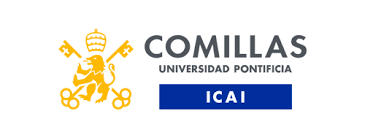

LEARNING OBJECTIVES
- How to apply bagging in classification trees
- Deep understanding of the variability created by boostrap in the ensemble of trees


---
## Import modules

In [1]:
import numpy as np # linear algebra
import pandas as pd  # data management (dataframes)
import matplotlib.pyplot as plt
import seaborn as sns  # plotting

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from sklearn.inspection import permutation_importance

from sklearn.ensemble import BaggingClassifier
#from sklearn.ensemble import BaggingRegressor

# solve problems with size and fonts in figures 
plt.rcParams['figure.dpi'] = 75

# auxiliary functions
import utils_ml1 as uml1
import utils_classification_ml2 as ucml2

### Functions for simplifying workflow with bagged trees

In [2]:
def fit_bagged_tree(number_estimators, Xtr, ytr, INPUTS):

    base_estimator =  Pipeline(steps=[('DT', 
                                        DecisionTreeClassifier( criterion='gini',  # impurity measure
                                                                min_samples_split=2, # Minimum number of obs in node to keep cutting
                                                                min_samples_leaf=1, # Minimum number of obs in a terminal node
                                                                random_state=999))]) # For replication


    bag_class_estim = BaggingClassifier(estimator=base_estimator,
                                        n_estimators=number_estimators,
                                        random_state=0)
                        
    # fit the bagged trees
    bag_class_estim.fit(Xtr[INPUTS], ytr)

    return bag_class_estim

def plot_variability_bagged_tree(bag_class_estim):

    # number of nodes in each tree of the ensemble
    node_count_trees = [t['DT'].tree_.node_count for t in bag_class_estim.estimators_]
    mean_number_nodes = np.mean(node_count_trees)

    # number of nodes in each tree of the ensemble
    depth_trees = [t['DT'].tree_.max_depth for t in bag_class_estim.estimators_]
    mean_depth_trees = np.mean(depth_trees)

    fig = plt.figure(figsize=(15, 4))
    ax1=plt.subplot(2,1,1)
    plt.plot(node_count_trees, '.-')
    plt.hlines(mean_number_nodes,0,100, color = 'green', label = f'Mean = {mean_number_nodes}')
    plt.ylabel('Nº of nodes')
    plt.legend()                   
    plt.grid()

    plt.subplot(2,1,2, sharex = ax1)
    plt.plot(depth_trees, '.-')
    plt.hlines(mean_depth_trees,0,100, color = 'red', label = f'Mean = {mean_depth_trees}')
    plt.ylabel('Depth of the tree')                       
    plt.xlabel('Tree of the ensemble') 
    plt.legend()                           
    plt.grid()
    plt.show()

    return

---
## 1. Classification problem

#### 1.1 Load the dataset

In [3]:
# Load file with the dataset
df = pd.read_csv('simDataTriangle.dat', sep = "\t")
print('Dataframe:')
print(df.head())

# Convert output variable to categorical
df.Y = df.Y.astype('category')

Dataframe:
         X1        X2        X3        X4        X5        X6    Y
0 -0.416315  5.704369 -0.520502  5.624744 -0.567509  5.657103  OUT
1 -0.052473  9.467372 -0.308278  9.518659 -0.028233  9.271118  OUT
2 -0.552123  7.329100 -0.563368  7.373105 -0.851291  7.175183  OUT
3  0.290578  7.804284  0.248642  7.461996 -0.038654  7.557059  INS
4  0.116236  7.472282  0.154657  7.231131  0.154816  7.462239  INS


#### 1.2 Exploratory analysis


Info variables:
               X1          X2          X3          X4          X5          X6
count  700.000000  700.000000  700.000000  700.000000  700.000000  700.000000
mean     0.484328    6.115594    0.488827    6.124073    0.487352    6.121143
std      0.606122    2.678621    0.633653    2.686707    0.632867    2.687277
min     -0.597901    0.010610   -0.906872   -0.182318   -0.973871   -0.090703
25%     -0.045126    4.507014   -0.009401    4.432009   -0.004716    4.415462
50%      0.475767    6.614707    0.508919    6.619594    0.479645    6.572260
75%      1.023133    8.265262    0.998416    8.306398    0.990994    8.278550
max      1.499564    9.976869    1.982567   10.558648    1.924748   10.294785


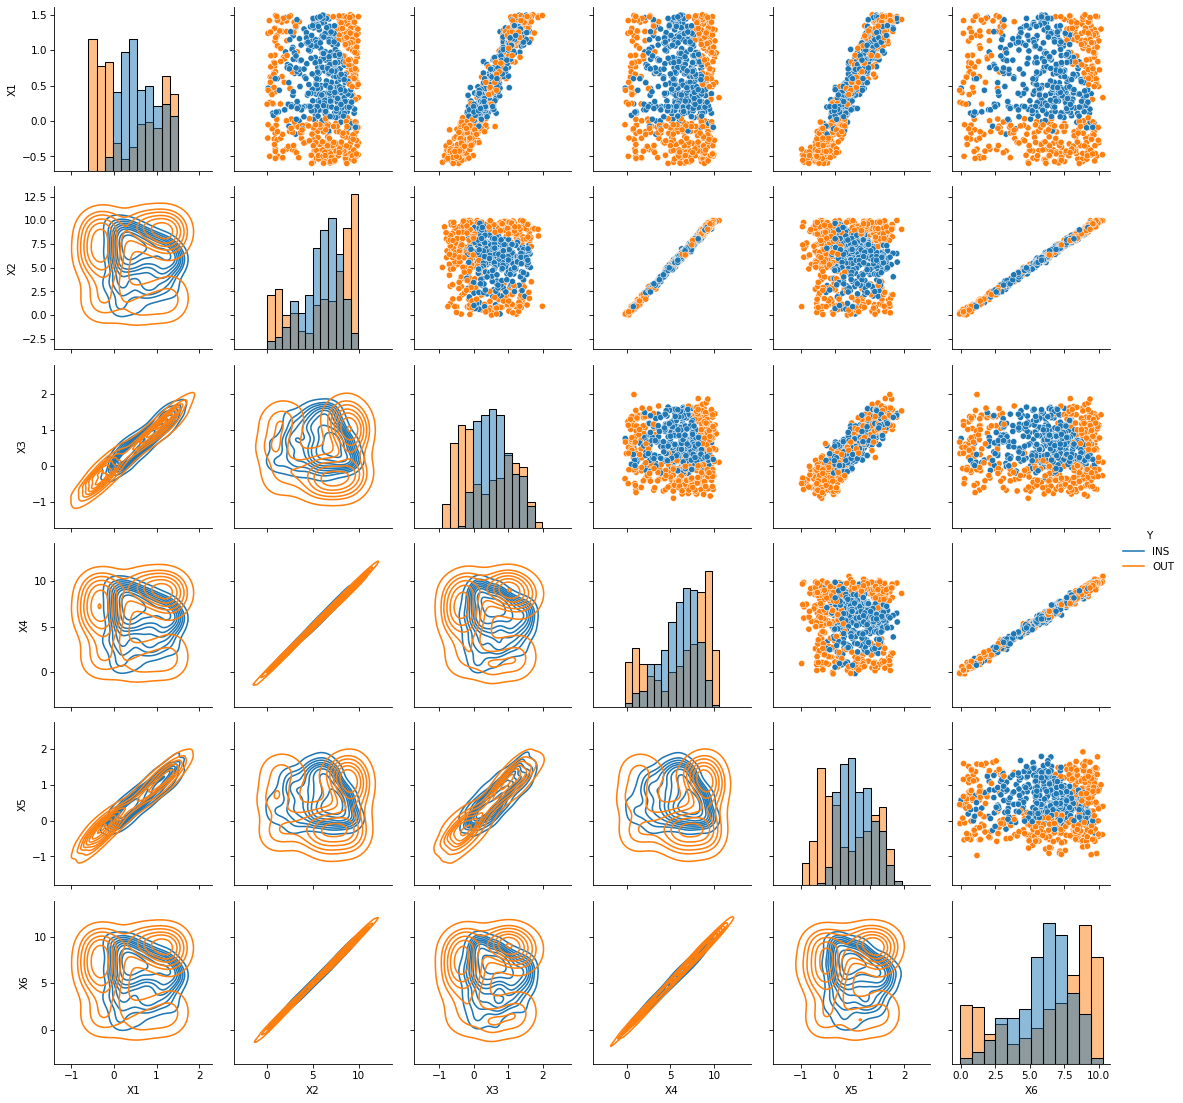

In [4]:
# Basic exploratory analysis

print('\nInfo variables:')
print(df.describe())

g = sns.PairGrid(df, hue="Y")
g.map_diag(sns.histplot)
#g.map_offdiag(sns.scatterplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.add_legend()

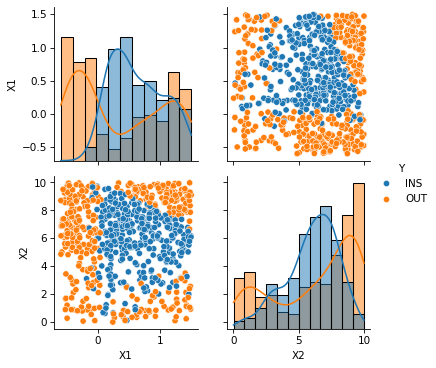

In [5]:
# Focus on interesting variables
g = sns.PairGrid(df, vars=["X1", "X2"], hue="Y")
g.map_diag(sns.histplot, kde=True)
g.map_offdiag(sns.scatterplot)
g.add_legend()

#### 1.3 Split the dataset in TR and TS

In [6]:
# Define input and output matrices
INPUTS = ['X1','X2','X3','X4','X5','X6']
OUTPUT = 'Y'
X = df[INPUTS]
y = df[OUTPUT]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0, #seed for replication
                                                    stratify = y)   #Preserves distribution of y

---
## 2: Fit ensembles of bagged trees using diffent sets of inputs

Six different ensembles are fitted for the same classification problem using the same hyperparameters (gridsearch is not used). The only difference is in the set of inputs variables using for training each ensemble

### 2.1: Fit a bagged tree with 100 trees using features X1 and X2

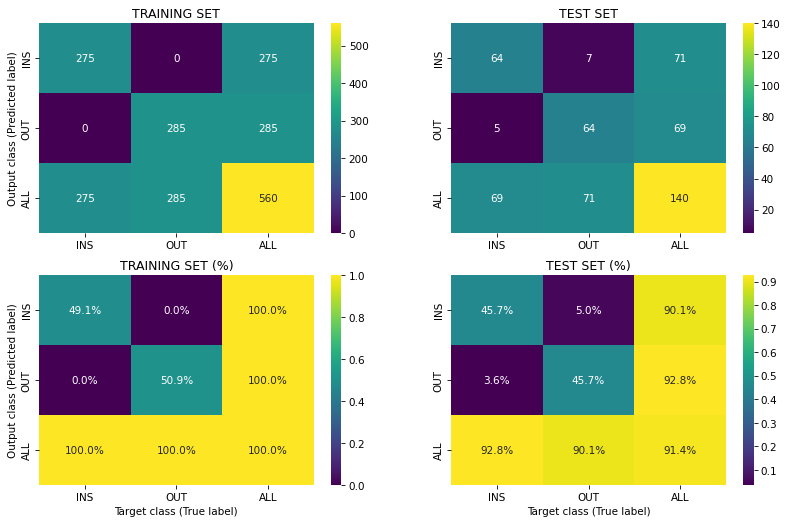

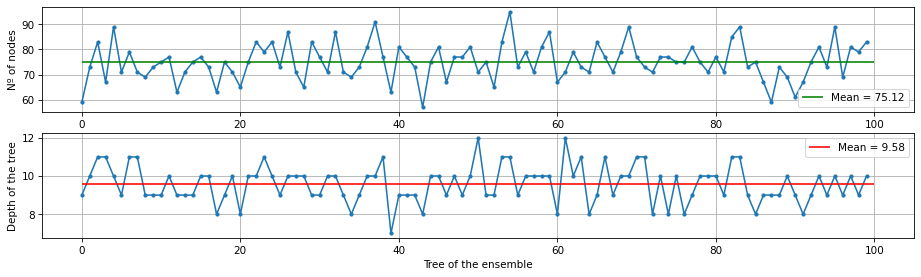

In [7]:
INPUTS_bt_1 = ['X1','X2']
bag_tree_1 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_1)
ucml2.plot_expanded_confusion_matrix(bag_tree_1, X_train[INPUTS_bt_1], y_train, X_test[INPUTS_bt_1], y_test)
plot_variability_bagged_tree(bag_tree_1)

### 2.2: Fit a bagged tree with 100 trees using features X1, X2, X3 and X4

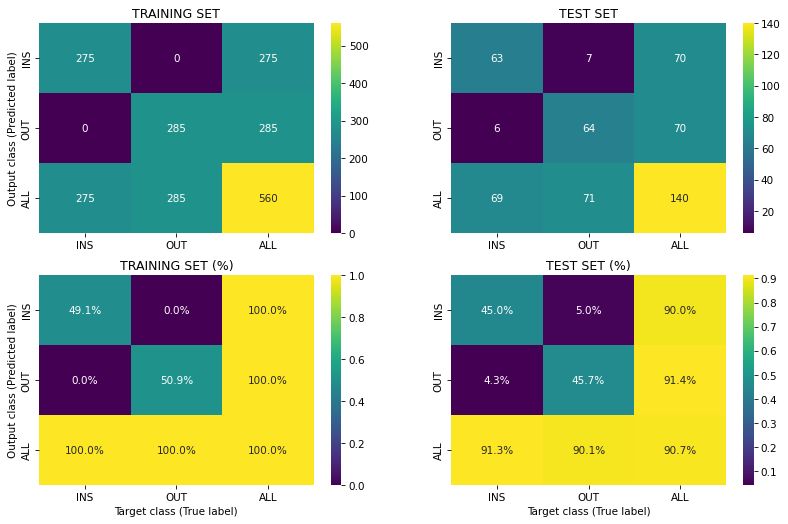

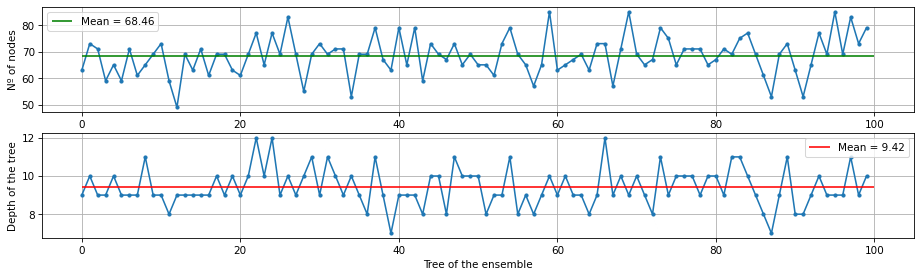

In [8]:
INPUTS_bt_2 = ['X1','X2','X3','X4']
bag_tree_2 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_2)
ucml2.plot_expanded_confusion_matrix(bag_tree_2, X_train[INPUTS_bt_2], y_train, X_test[INPUTS_bt_2], y_test)
plot_variability_bagged_tree(bag_tree_2)

## Baja el número de nodos: es lógico, porque hay más variables y encuentra más fácilmente los cortes.

### 2.3: Fit a bagged tree with 100 trees using features X1, X2, X3, X4, X5 and X6

Using ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']


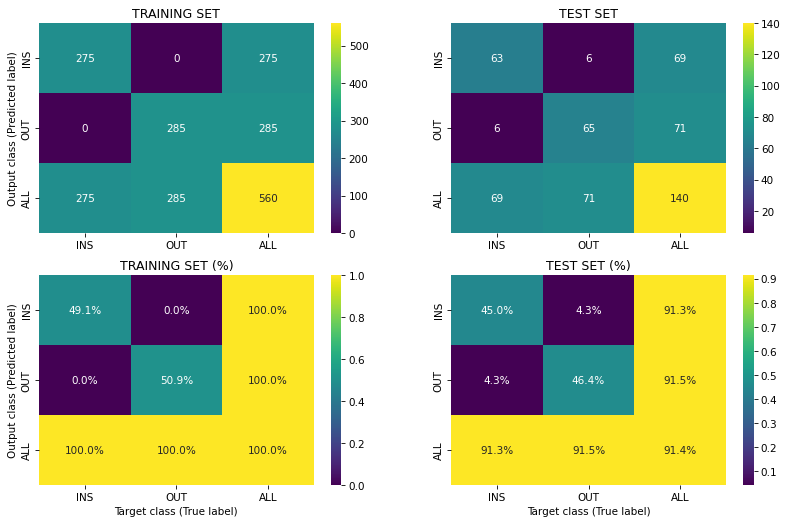

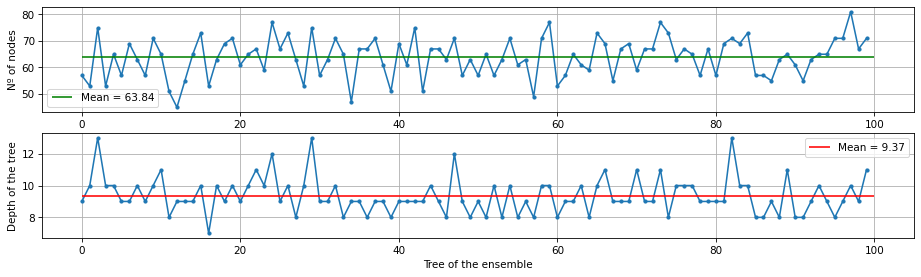

In [9]:
INPUTS_bt_3 = ['X1','X2','X3','X4','X5','X6']
bag_tree_3 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_3)
print(f'Using {INPUTS_bt_3}')
ucml2.plot_expanded_confusion_matrix(bag_tree_3, X_train[INPUTS_bt_3], y_train, X_test[INPUTS_bt_3], y_test)
plot_variability_bagged_tree(bag_tree_3)

### 2.4: Fit a bagged tree with 100 trees using features X3 and X4

Using ['X3', 'X4']


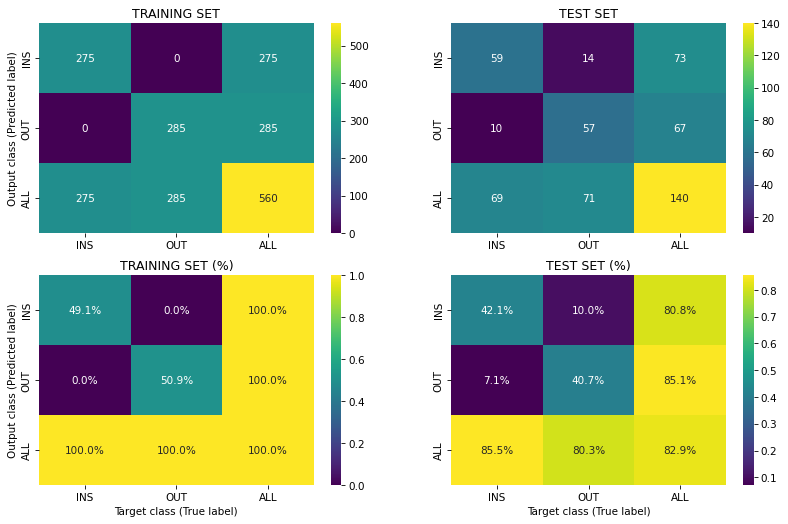

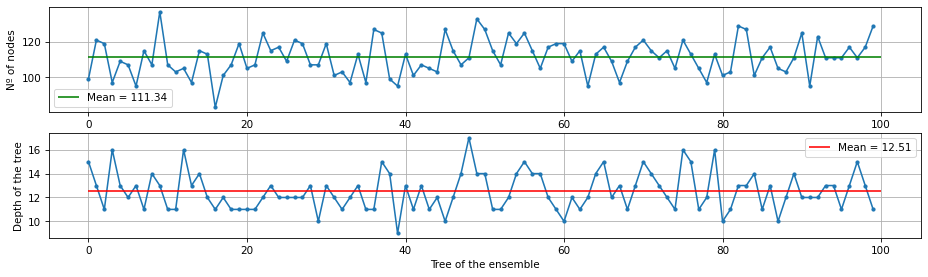

In [11]:
INPUTS_bt_4 = ['X3','X4']
bag_tree_4 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_4)
print(f'Using {INPUTS_bt_4}')
ucml2.plot_expanded_confusion_matrix(bag_tree_4, X_train[INPUTS_bt_4], y_train, X_test[INPUTS_bt_4], y_test)
plot_variability_bagged_tree(bag_tree_4)

## Si les pasamos X3 y X4, el árbol es más grande (tanto en número de nodos como en profundidad) porque son peores variables explicativas.

### 2.5: Fit a bagged tree with 100 trees using features X5 and X6

Using ['X5', 'X6']


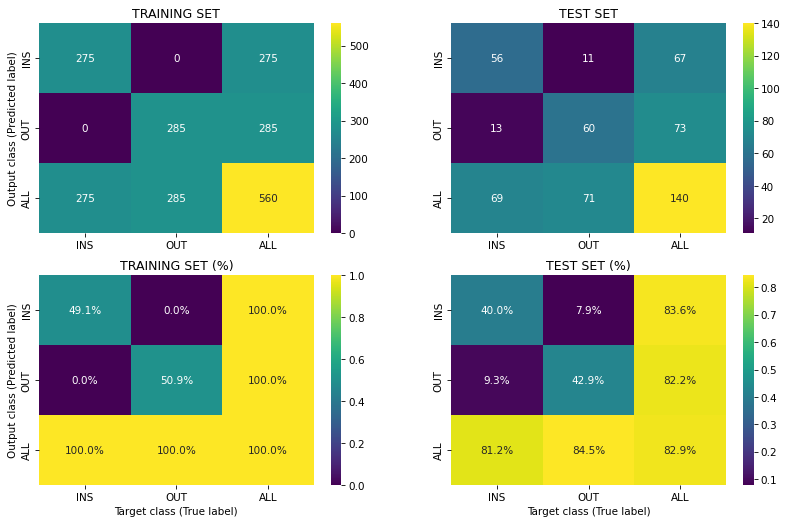

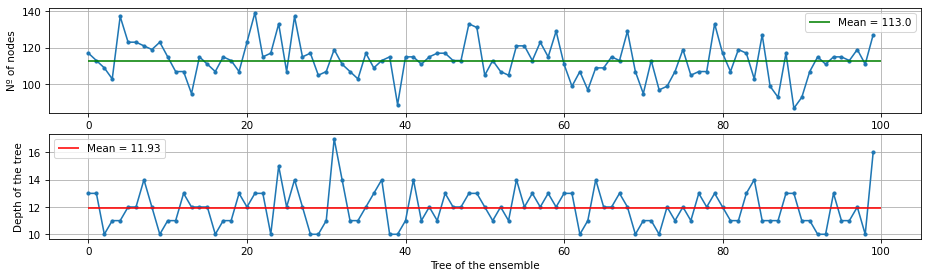

In [12]:
INPUTS_bt_5 = ['X5', 'X6']
bag_tree_5 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_5)
print(f'Using {INPUTS_bt_5}')
ucml2.plot_expanded_confusion_matrix(bag_tree_5, X_train[INPUTS_bt_5], y_train, X_test[INPUTS_bt_5], y_test)
plot_variability_bagged_tree(bag_tree_5)

### 2.6: Fit a bagged tree with 100 trees using features X3, X4, X5 and X6

Using ['X3', 'X4', 'X5', 'X6']


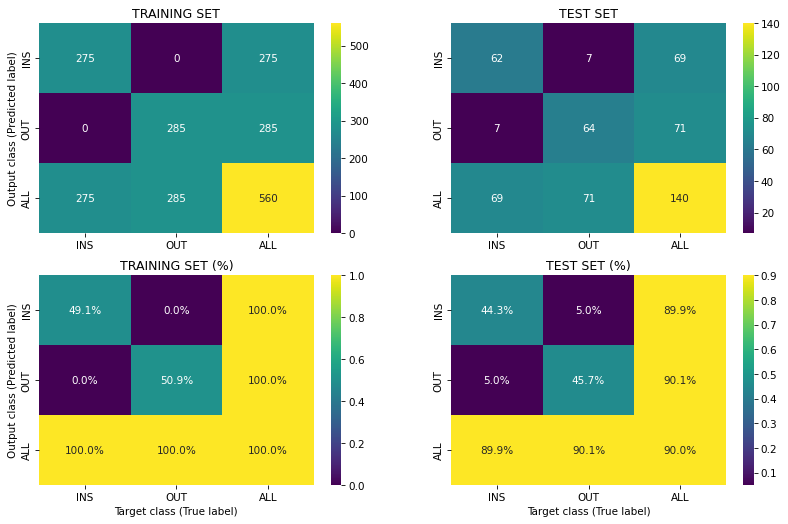

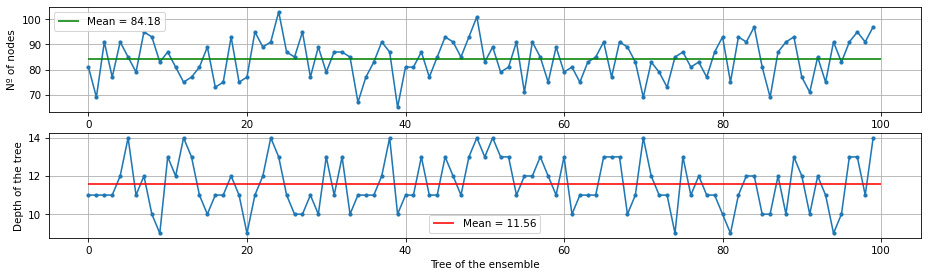

In [12]:
INPUTS_bt_6 = ['X3','X4', 'X5','X6']
bag_tree_6 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_6)
print(f'Using {INPUTS_bt_6}')
ucml2.plot_expanded_confusion_matrix(bag_tree_6, X_train[INPUTS_bt_6], y_train, X_test[INPUTS_bt_6], y_test)
plot_variability_bagged_tree(bag_tree_6)

### Questions

Q1. Are there statistically significant differences in the number of nodes and depth of the trees with the ensemble?

Habría que analizar la media de los nodos y la desviación típica. Hay diferencias 

Q2. Which bagged tree is the worst in terms of accuracy?

Q3. why the bag_tree_6 is better than bag_tree_4 and bag_tree_5?

Q4. Which is the best bagged tree?

Q5. Why the complexities of bag_tree_4 and bag_tree_3 are so different?